# QCut vs qiskit-addon-cutting

Load env with `uv sync --group benchmark`.

In [1]:
import ctypes
import gc
import math
import platform
from time import perf_counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import psutil
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import CXGate, RXXGate, RZZGate, efficient_su2
from qiskit.quantum_info import PauliList, SparsePauliOp
from qiskit_addon_cutting import (
    DeviceConstraints,
    OptimizationParameters,
    cut_wires,
    expand_observables,
    find_cuts,
    generate_cutting_experiments,
    partition_problem,
    reconstruct_expectation_values,
)
from qiskit_addon_cutting.instructions import CutWire
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2

import QCut as ck
from QCut import CutOptions, cut, cutGate
from QCut.qpd.qpd_operations import plan_cost

## Circuit families

Each returns the circuit marked for QCut, the circuit for the addon, and how the addon should split it. The cuts land in the same places for both.
`mixed_axes` is here because on single axis QCut will win on the joint decomposition for parallel rotations but for mixed axes this is not possible.
On `mixed_axes` QCut wins due to `consolidate` merging consecutive cut gates.

In [2]:
def single_z(width):
    return SparsePauliOp(["I" * (width - 1 - i) + "Z" + "I" * i for i in range(width)])


def parallel_rotations(pairs):
    """`pairs` rotation gates crossing one split, all schedulable at once."""
    width = 2 * pairs
    marked, plain = QuantumCircuit(width), QuantumCircuit(width)
    for c in (marked, plain):
        for q in range(width):
            c.ry(0.3 + 0.1 * q, q)
        # holds each half together, or the circuit falls into single-qubit pieces
        for q in range(pairs - 1):
            c.rzz(0.4, q, q + 1)
            c.rzz(0.4, pairs + q, pairs + q + 1)
    for i in range(pairs):
        marked.append(**cutGate(RZZGate(0.5 + 0.15 * i), i, pairs + i))
        plain.rzz(0.5 + 0.15 * i, i, pairs + i)
    return marked, plain, "A" * pairs + "B" * pairs, False


def parallel_wires(wires):
    """`wires` wires cut at the same point."""
    width = wires + 2
    marked, addon = QuantumCircuit(width), QuantumCircuit(width)
    for c in (marked, addon):
        c.h(0)
        for q in range(1, wires + 1):
            c.cx(0, q)
    for q in range(1, wires + 1):
        marked.append(cut(), [q])
        addon.append(CutWire(), [q])
    for c in (marked, addon):
        for q in range(1, wires + 1):
            c.cx(q, width - 1)
    return marked, addon, None, True


def qaoa_layer(nodes, degree=2, seed=7):
    """One QAOA layer on a random regular graph, split down the middle."""
    graph = nx.random_regular_graph(degree, nodes, seed=seed)
    half = nodes // 2
    marked, plain = QuantumCircuit(nodes), QuantumCircuit(nodes)
    for c in (marked, plain):
        for q in range(nodes):
            c.h(q)
    for a, b in graph.edges():
        plain.rzz(0.8, a, b)
        if (a < half) != (b < half):
            marked.append(**cutGate(RZZGate(0.8), a, b))
        else:
            marked.rzz(0.8, a, b)
    for c in (marked, plain):
        for q in range(nodes):
            c.rx(0.6, q)
    return marked, plain, "A" * half + "B" * (nodes - half), False


def mixed_axes(pairs):
    """rzz then rxx on each crossing pair: the product is a generic unitary, so it
    cannot be bundled and consolidation matters."""
    width = 2 * pairs
    marked, plain = QuantumCircuit(width), QuantumCircuit(width)
    for c in (marked, plain):
        for q in range(width):
            c.ry(0.3 + 0.1 * q, q)
        for q in range(pairs - 1):
            c.rzz(0.4, q, q + 1)
            c.rzz(0.4, pairs + q, pairs + q + 1)
    for i in range(pairs):
        marked.append(**cutGate(RZZGate(0.7), i, pairs + i))
        marked.append(**cutGate(RXXGate(0.9), i, pairs + i))
        plain.rzz(0.7, i, pairs + i)
        plain.rxx(0.9, i, pairs + i)
    return marked, plain, "A" * pairs + "B" * pairs, False


FAMILIES = {
    "parallel rotations": (parallel_rotations, [1, 2, 3]),
    "parallel wires": (parallel_wires, [1, 2, 3]),
    "QAOA layer": (qaoa_layer, [4, 5, 6]),
    "mixed axes": (mixed_axes, [1, 2, 3]),
}

## Same cuts, both libraries

In [3]:
def budget_from(labels):
    """The addon is told how to partition, so QCut has to be given the same budget.

    Left free, QCut splits into the circuit's natural connected components, which can be
    more pieces than the labels ask for. Same gamma, but more circuits per group, so the
    counts would not be comparable.
    """
    if labels is None:
        return None
    return [labels.count(label) for label in dict.fromkeys(labels)]


def run_qcut(marked, observables, options=None, max_qubits=None):
    t = perf_counter()
    circuit = ck.get_locations_and_subcircuits(
        marked.copy(), max_qubits=max_qubits, options=options
    )
    experiment = ck.get_experiment_circuits(circuit, observables)
    seconds = perf_counter() - t
    return (
        float(experiment.gamma),
        int(experiment.num_circuits),
        seconds,
        len(circuit.subcircuits),
    )


def run_addon(circuit, observables, labels, wire_cuts):
    paulis = PauliList([p.to_label() for p in observables.paulis])
    t = perf_counter()
    if wire_cuts:
        expanded = cut_wires(circuit)
        problem = partition_problem(
            circuit=expanded,
            observables=expand_observables(paulis, circuit, expanded),
        )
    else:
        problem = partition_problem(
            circuit=circuit, partition_labels=labels, observables=paulis
        )
    subexperiments, coefficients = generate_cutting_experiments(
        circuits=problem.subcircuits,
        observables=problem.subobservables,
        num_samples=np.inf,
    )
    # the coefficient 1-norm, not prod(basis.overhead), which would be gamma squared
    gamma = float(sum(abs(w) for w, _ in coefficients))
    count = int(sum(len(g) for g in subexperiments.values()))
    return gamma, count, perf_counter() - t, len(problem.subcircuits)


exact = CutOptions(expansion="exact")

rows = []
for family, (build, sizes) in FAMILIES.items():
    for size in sizes:
        marked, addon, labels, wire_cuts = build(size)
        observables = single_z(marked.num_qubits)
        budget = budget_from(labels)
        for library, (gamma, count, seconds, pieces) in (
            ("QCut", run_qcut(marked, observables, exact, budget)),
            ("addon", run_addon(addon, observables, labels, wire_cuts)),
        ):
            rows.append(
                {
                    "family": family,
                    "size": size,
                    "library": library,
                    "gamma": gamma,
                    "circuits": count,
                    "pieces": pieces,
                    "seconds": seconds,
                }
            )

same = pd.DataFrame(rows)
same["shots"] = same["gamma"] ** 2
same

,family,size,library,gamma,circuits,pieces,seconds,shots
0,parallel rotations,1,QCut,1.958851,12,2,0.011637,3.837098
1,parallel rotations,1,addon,1.958851,12,2,0.002774,3.837098
2,parallel rotations,2,QCut,3.749508,60,2,0.024349,14.058807
3,parallel rotations,2,addon,4.329791,72,2,0.009562,18.747092
4,parallel rotations,3,QCut,7.156596,264,2,0.165698,51.216862
5,parallel rotations,3,addon,10.541795,432,2,0.068707,111.129448
6,parallel wires,1,QCut,4.000000,16,2,0.002899,16.000000
7,parallel wires,1,addon,4.000000,16,2,0.003131,16.000000
8,parallel wires,2,QCut,7.000000,56,2,0.009301,49.000000
9,parallel wires,2,addon,16.000000,128,2,0.017965,256.000000


In [4]:
wide = same.pivot_table(
    index=["family", "size"],
    columns="library",
    values=["gamma", "circuits", "pieces", "seconds"],
)
ratio = pd.DataFrame(
    {
        "gamma QCut/addon": wide["gamma"]["QCut"] / wide["gamma"]["addon"],
        "shots QCut/addon": (wide["gamma"]["QCut"] / wide["gamma"]["addon"]) ** 2,
        "circuits QCut/addon": wide["circuits"]["QCut"] / wide["circuits"]["addon"],
        # if this is not 1 the two are not cutting into the same number of pieces, and
        # the circuit ratio above is measuring that rather than the decomposition
        "pieces QCut/addon": wide["pieces"]["QCut"] / wide["pieces"]["addon"],
        "build time QCut/addon": wide["seconds"]["QCut"] / wide["seconds"]["addon"],
    }
)
ratio.round(3)

gamma QCut/addon  shots QCut/addon  \
family             size                                       
QAOA layer         4                1.000             1.000   
                   5                1.000             1.000   
                   6                1.000             1.000   
mixed axes         1                0.828             0.686   
                   2                0.686             0.470   
                   3                0.568             0.323   
parallel rotations 1                1.000             1.000   
                   2                0.866             0.750   
                   3                0.679             0.461   
parallel wires     1                1.000             1.000   
                   2                0.438             0.191   
                   3                0.234             0.055   

                         circuits QCut/addon  pieces QCut/addon  \
family             size                                           
QAOA layer         4                   1.000                1.0   
                   5                   1.000                1.0   
                   6                   1.000                1.0   
mixed axes         1                   0.833                1.0   
                   2                   0.694                1.0   
                   3                   0.579                1.0   
parallel rotations 1                   1.000                1.0   
                   2                   0.833                1.0   
                   3                   0.611                1.0   
parallel wires     1                   1.000                1.0   
                   2                   0.438                1.0   
                   3                   0.234                1.0   

                         build time QCut/addon  
family             size                         
QAOA layer         4                     1.221  
                   5                     0.758  
                   6                     0.813  
mixed axes         1                     1.903  
                   2                     0.678  
                   3                     0.278  
parallel rotations 1                     4.194  
                   2                     2.546  
                   3                     2.412  
parallel wires     1                     0.926  
                   2                     0.518  
                   3                     0.178

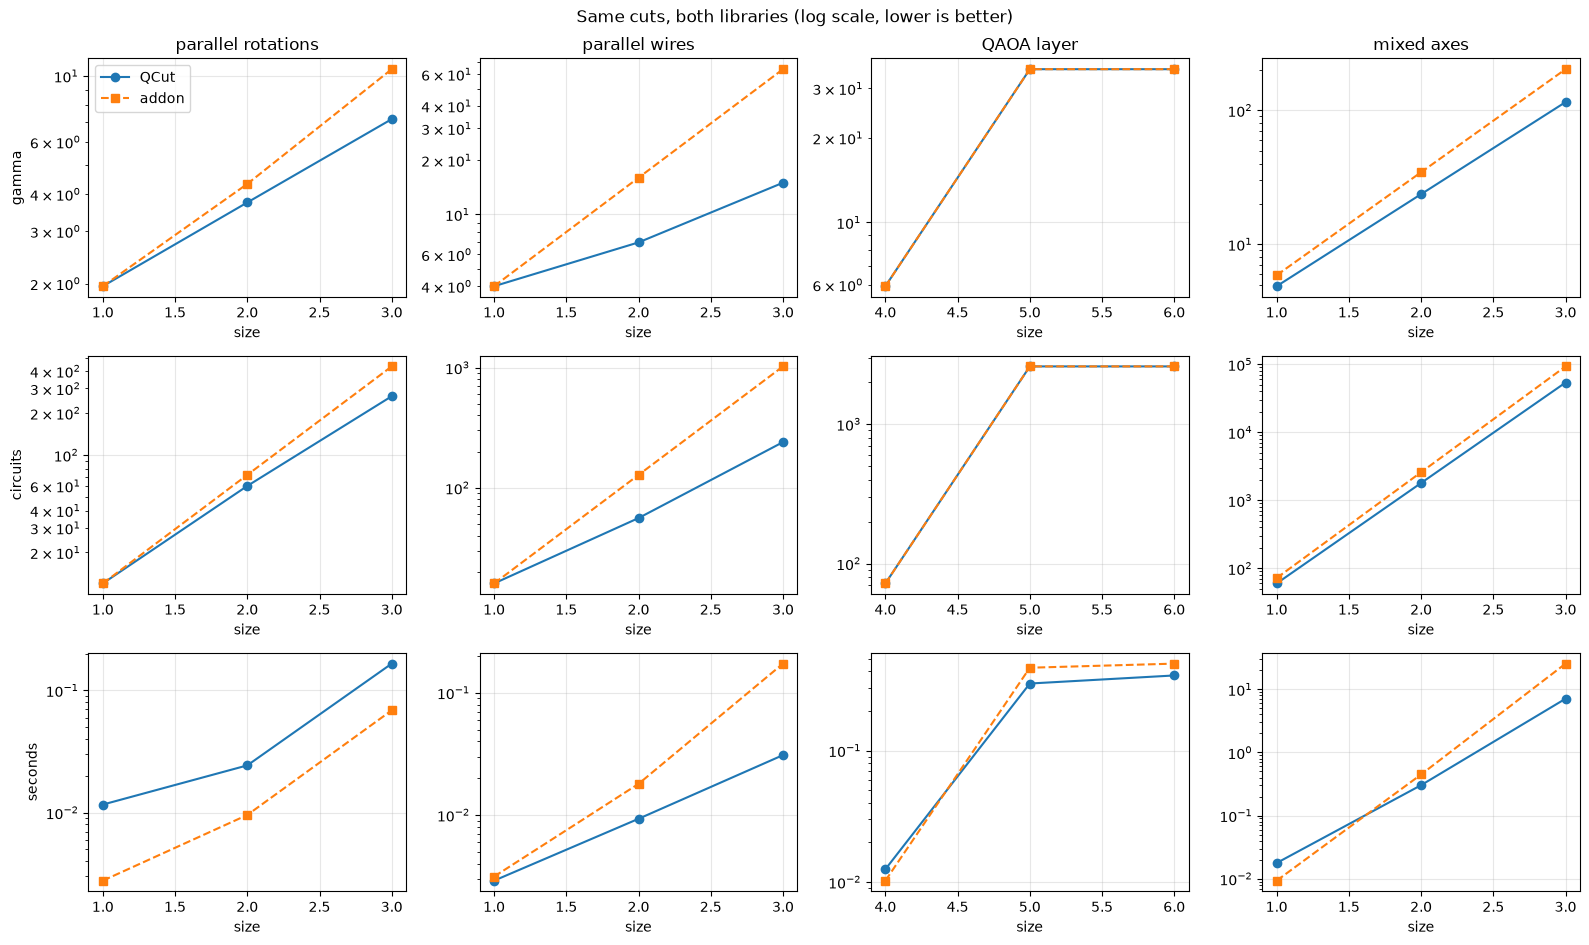

In [5]:
families = list(FAMILIES)
metrics = ("gamma", "circuits", "seconds")
fig, axes = plt.subplots(
    len(metrics), len(families), figsize=(4 * len(families), 3.2 * len(metrics))
)

for column, family in enumerate(families):
    block = same[same.family == family]
    for row, metric in enumerate(metrics):
        ax = axes[row, column]
        for library, marker in (("QCut", "o-"), ("addon", "s--")):
            part = block[block.library == library].sort_values("size")
            ax.plot(part["size"], part[metric], marker, label=library)
        ax.set_yscale("log")
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(family)
        if column == 0:
            ax.set_ylabel(metric)
        ax.set_xlabel("size")

axes[0, 0].legend()
fig.suptitle("Same cuts, both libraries (log scale, lower is better)")
fig.tight_layout()

## Which QCut option is responsible

The addon has no equivalent of consolidation, joint rotation cutting or of communicating wire cuts, so turning them off should reproduce its numbers.

In [6]:
off = CutOptions(
    joint_rotation_cuts=False,
    wire_cut_communication="never",
    consolidate="never",
    expansion="exact",
)

rows = []
for family, (build, sizes) in FAMILIES.items():
    for size in sizes:
        marked, _addon, labels, _wire_cuts = build(size)
        plain_gamma, *_ = run_qcut(
            marked, single_z(marked.num_qubits), off, budget_from(labels)
        )
        block = same[(same.family == family) & (same["size"] == size)]
        rows.append(
            {
                "family": family,
                "size": size,
                "addon": float(block[block.library == "addon"]["gamma"].iloc[0]),
                "qcut_features_off": plain_gamma,
                "qcut_default": float(block[block.library == "QCut"]["gamma"].iloc[0]),
            }
        )

attribution = pd.DataFrame(rows)
attribution["off == addon"] = np.isclose(
    attribution["qcut_features_off"], attribution["addon"], rtol=1e-6
)
attribution.round(4)

,family,size,addon,qcut_features_off,qcut_default,off == addon
0,parallel rotations,1,1.9589,1.9589,1.9589,True
1,parallel rotations,2,4.3298,4.3298,3.7495,True
2,parallel rotations,3,10.5418,10.5418,7.1566,True
3,parallel wires,1,4.0000,4.0000,4.0000,True
4,parallel wires,2,16.0000,16.0000,7.0000,True
5,parallel wires,3,64.0000,64.0000,15.0000,True
6,QAOA layer,4,5.9278,5.9278,5.9278,True
7,QAOA layer,5,35.1391,35.1391,35.1391,True
8,QAOA layer,6,35.1391,35.1391,35.1391,True
9,mixed axes,1,5.8736,5.8736,4.8644,True


## Generating the experiment circuits

`QCut baseline` is QCut with the features the addon has no equivalent of turned off, which makes it build the same number of circuits over the same subcircuits. `QCut` is what the defaults actually produce, and its totals are lower mainly because there is less to build.

The same decomposition does not mean the exact same circuits. QCut's carry 15 to 30% more instructions, since its operations are derived from the gate's own matrix and keep what the addon's analytic tables have folded into their entries. So `us/op` is the column that compares the generation itself.

In [7]:
# sizes large enough that the resident reading is not dominated by its own noise
GENERATION = {
    "parallel rotations": [3, 4, 5],
    "parallel wires": [3, 4, 5],
    "mixed axes": [2, 3],
}

# under this the reading is the allocator moving pages around rather than the result:
# repeats of the smallest case have come out 0.51, 0.26 and -0.61 MB
MEASURABLE = 5e6

PROCESS = psutil.Process()
LIBC = ctypes.CDLL("libc.so.6") if platform.libc_ver()[0] == "glibc" else None


def rss():
    """Resident memory, with the pages the process has freed handed back first.

    glibc keeps them, and then a case that allocates into what an earlier one released
    grows no resident memory at all and reads as free.
    """
    gc.collect()
    if LIBC is not None:
        LIBC.malloc_trim(0)
    return PROCESS.memory_info().rss


def generators(family, size):
    """Each library's generation step for one case, with the planning already done.

    `QCut baseline` turns off everything the addon has no equivalent of, so the two
    build the same number of circuits over the same subcircuits.
    """
    build, _sizes = FAMILIES[family]
    marked, addon, labels, wire_cuts = build(size)
    observables = single_z(marked.num_qubits)
    budget = budget_from(labels)

    def qcut(options):
        cut_circuit = ck.get_locations_and_subcircuits(
            marked.copy(), max_qubits=budget, options=options
        )

        def generate():
            experiment = ck.get_experiment_circuits(cut_circuit, observables)
            return experiment, experiment.num_circuits

        return generate

    paulis = PauliList([p.to_label() for p in observables.paulis])
    if wire_cuts:
        expanded = cut_wires(addon)
        problem = partition_problem(
            circuit=expanded, observables=expand_observables(paulis, addon, expanded)
        )
    else:
        problem = partition_problem(
            circuit=addon, partition_labels=labels, observables=paulis
        )

    def addon_experiments():
        subexperiments, _coefficients = generate_cutting_experiments(
            circuits=problem.subcircuits,
            observables=problem.subobservables,
            num_samples=np.inf,
        )
        return subexperiments, int(sum(len(g) for g in subexperiments.values()))

    return {
        "QCut baseline": qcut(off),
        "addon": addon_experiments,
        "QCut": qcut(exact),
    }


def instructions(held):
    """Operations over every generated circuit, whichever container they came in."""
    if isinstance(held, dict):
        circuits = [circuit for group in held.values() for circuit in group]
    else:
        circuits = [
            circuit
            for group in held.experiments
            for subcircuits in group
            for circuit in subcircuits.values()
        ]
    return sum(circuit.size() for circuit in circuits)


def measure_memory(build):
    """Resident growth from holding the result, which is what has to be kept until the
    circuits are submitted. NaN when the result is too small to read."""
    before = rss()
    held, count = build()
    memory = rss() - before
    ops = instructions(held)
    del held
    return count, memory if memory >= MEASURABLE else float("nan"), ops


def measure_time(build, repeats=3, budget=5.0):
    """Best of a few, so a gc pause does not set the number, but no more than
    `budget` seconds of it: the largest cases take that long in one build."""
    best, spent = math.inf, 0.0
    for _ in range(repeats):
        gc.collect()
        start = perf_counter()
        held, _count = build()
        elapsed = perf_counter() - start
        del held
        best, spent = min(best, elapsed), spent + elapsed
        if spent > budget:
            break
    return best


rows = []
for family, sizes in GENERATION.items():
    for size in sizes:
        for library, build in generators(family, size).items():
            # timed first: building and freeing the case a few times also settles the
            # heap, so the reading below starts from this case's own floor
            seconds = measure_time(build)
            count, memory, ops = measure_memory(build)
            rows.append(
                {
                    "family": family,
                    "size": size,
                    "library": library,
                    "circuits": count,
                    "ops/circuit": ops / count,
                    "MB": memory / 1e6,
                    "seconds": seconds,
                    "us/circuit": seconds / count * 1e6,
                    "kB/circuit": memory / count / 1e3,
                    "us/op": seconds / ops * 1e6,
                }
            )

generation = pd.DataFrame(rows)

# the baseline has to be building the same thing as the addon, or the two are not
# comparable circuit for circuit
counts = generation.pivot_table(
    index=["family", "size"], columns="library", values="circuits"
)
assert (counts["QCut baseline"] == counts["addon"]).all()

generation.round(2)

,family,size,library,circuits,ops/circuit,MB,seconds,us/circuit,kB/circuit,us/op
0,parallel rotations,3,QCut baseline,432,12.50,NaN,0.04,85.36,NaN,6.83
1,parallel rotations,3,addon,432,10.50,NaN,0.06,139.95,NaN,13.33
2,parallel rotations,3,QCut,264,13.37,NaN,0.08,314.78,NaN,23.54
3,parallel rotations,4,QCut baseline,2592,17.00,17.68,0.25,94.65,6.82,5.57
4,parallel rotations,4,addon,2592,14.33,13.86,0.48,185.55,5.35,12.95
5,parallel rotations,4,QCut,1104,18.39,8.16,0.43,387.37,7.39,21.06
6,parallel rotations,5,QCut baseline,15552,21.50,137.03,2.18,140.16,8.81,6.52
7,parallel rotations,5,addon,15552,18.17,114.81,3.68,236.64,7.38,13.03
8,parallel rotations,5,QCut,4512,23.46,35.90,2.60,576.86,7.96,24.59
9,parallel wires,3,QCut baseline,1024,12.00,NaN,0.06,55.65,NaN,4.64


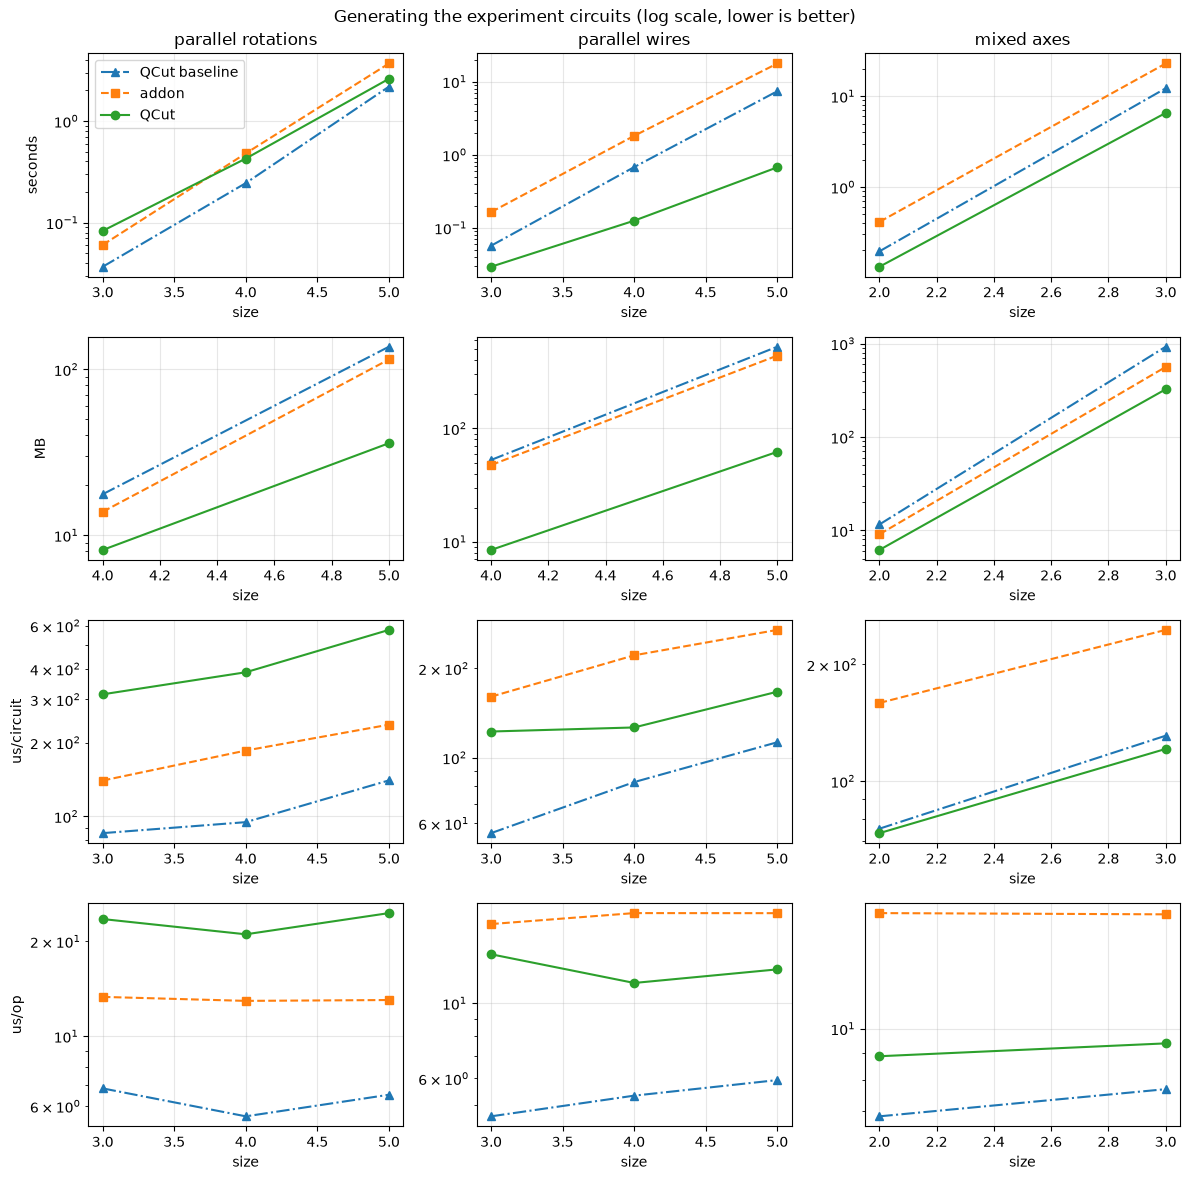

In [8]:
gen_families = list(GENERATION)
gen_metrics = ("seconds", "MB", "us/circuit", "us/op")
fig, axes = plt.subplots(
    len(gen_metrics),
    len(gen_families),
    figsize=(4 * len(gen_families), 3 * len(gen_metrics)),
)

for column, family in enumerate(gen_families):
    block = generation[generation.family == family]
    for row, metric in enumerate(gen_metrics):
        ax = axes[row, column]
        for library, marker in (
            ("QCut baseline", "^-."),
            ("addon", "s--"),
            ("QCut", "o-"),
        ):
            part = block[block.library == library].sort_values("size")
            ax.plot(part["size"], part[metric], marker, label=library)
        ax.set_yscale("log")
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(family)
        if column == 0:
            ax.set_ylabel(metric)
        ax.set_xlabel("size")

axes[0, 0].legend()
fig.suptitle("Generating the experiment circuits (log scale, lower is better)")
fig.tight_layout()

## Reading the results back

Turning subexperiment counts into expectation values, timed on its own with the circuits already run. Two shapes are worth separating: a few observables spread across the circuit, and every Z string over `k` qubits, which is what reconstructing a distribution asks for.

The addon reads one observable at a time over the counts it saw, in Rust, so its cost per observable is set by the shot count rather than by the width. QCut reads each subcircuit once per group and multiplies, and takes the whole Z basis in one transform when the observables are dense in the qubits they span between them.

In [9]:
RECONSTRUCTION_SHOTS = 4000
sampler = SamplerV2()


def chain(width):
    """One gate cut across the middle, each half held together by its own chain."""
    marked, plain = QuantumCircuit(width), QuantumCircuit(width)
    for c in (marked, plain):
        for qubit in range(width):
            c.ry(0.3 + 0.07 * qubit, qubit)
        for qubit in range(width // 2 - 1):
            c.cx(qubit, qubit + 1)
            c.cx(width // 2 + qubit, width // 2 + qubit + 1)
    marked.append(**cutGate(CXGate(), width // 2 - 1, width // 2))
    plain.cx(width // 2 - 1, width // 2)
    return marked, plain, "A" * (width // 2) + "B" * (width // 2)


def z_strings(width, over):
    """Every Z string over the first `over` qubits, identity excluded."""
    labels = []
    for i in range(1, 1 << over):
        label = ["I"] * width
        for bit in range(over):
            if (i >> bit) & 1:
                label[width - 1 - bit] = "Z"
        labels.append("".join(label))
    return SparsePauliOp(labels)


def read_qcut(marked, observables):
    """Run the experiment, then time turning its counts into expectation values."""
    experiment = ck.get_experiment_circuits(
        ck.get_locations_and_subcircuits(marked.copy()), observables
    )
    results = ck.run_experiments(
        experiment, shots=RECONSTRUCTION_SHOTS, backend=AerSimulator()
    )
    t = perf_counter()
    ck.estimate_expectation_values(results)
    return perf_counter() - t


def read_addon(plain, observables, labels):
    paulis = PauliList([p.to_label() for p in observables.paulis])
    problem = partition_problem(
        circuit=plain, partition_labels=labels, observables=paulis
    )
    subexperiments, coefficients = generate_cutting_experiments(
        circuits=problem.subcircuits,
        observables=problem.subobservables,
        num_samples=np.inf,
    )
    results = {
        label: sampler.run(
            [transpile(circuit, AerSimulator()) for circuit in circuits],
            shots=RECONSTRUCTION_SHOTS,
        ).result()
        for label, circuits in subexperiments.items()
    }
    t = perf_counter()
    reconstruct_expectation_values(results, coefficients, problem.subobservables)
    return perf_counter() - t


rows = []
for width in (8, 12, 16, 20, 24):
    marked, plain, labels = chain(width)
    observables = single_z(width)
    rows.append(
        {
            "kind": "one Z per qubit",
            "size": width,
            "observables": len(observables),
            "QCut": read_qcut(marked, observables),
            "addon": read_addon(plain, observables, labels),
        }
    )

for over in (4, 6, 8, 10, 12):
    marked, plain, labels = chain(16)
    observables = z_strings(16, over)
    rows.append(
        {
            "kind": "every Z string",
            "size": over,
            "observables": len(observables),
            "QCut": read_qcut(marked, observables),
            "addon": read_addon(plain, observables, labels),
        }
    )

reconstruction = pd.DataFrame(rows)
reconstruction["addon/QCut"] = reconstruction["addon"] / reconstruction["QCut"]
reconstruction.round(3)

/home/nivalajo/work/QCut/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,kind,size,observables,QCut,addon,addon/QCut
0,one Z per qubit,8,8,0.004,0.099,24.253
1,one Z per qubit,12,12,0.006,0.109,19.401
2,one Z per qubit,16,16,0.016,0.125,7.674
3,one Z per qubit,20,20,0.038,0.135,3.597
4,one Z per qubit,24,24,0.085,0.149,1.759
5,every Z string,4,15,0.014,0.124,8.964
6,every Z string,6,63,0.022,0.250,11.572
7,every Z string,8,255,0.050,0.762,15.301
8,every Z string,10,1023,0.164,0.908,5.554
9,every Z string,12,4095,0.633,1.483,2.343


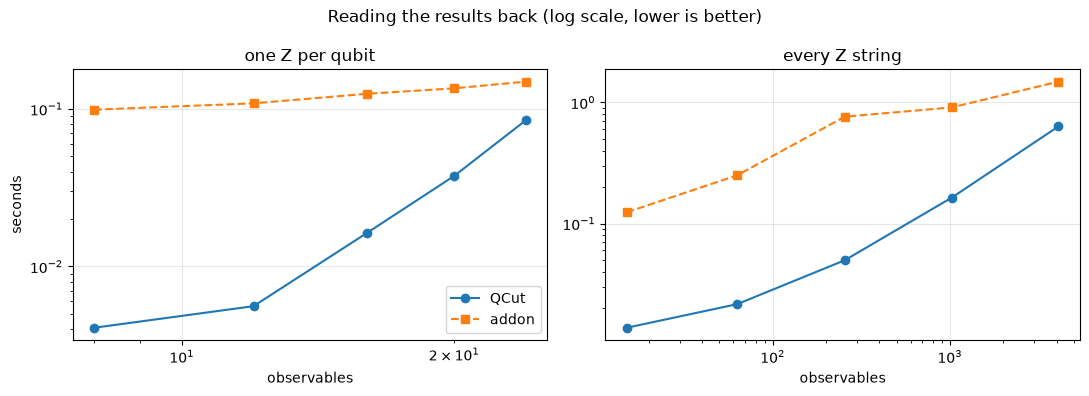

In [10]:
kinds = list(dict.fromkeys(reconstruction["kind"]))
fig, axes = plt.subplots(1, len(kinds), figsize=(5.5 * len(kinds), 4))

for ax, kind in zip(axes, kinds):
    block = reconstruction[reconstruction.kind == kind].sort_values("observables")
    for library, marker in (("QCut", "o-"), ("addon", "s--")):
        ax.plot(block["observables"], block[library], marker, label=library)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.set_title(kind)
    ax.set_xlabel("observables")

axes[0].set_ylabel("seconds")
axes[0].legend()
fig.suptitle("Reading the results back (log scale, lower is better)")
fig.tight_layout()

## Automatic cut finding

Each library picks its own cuts under the same qubit budget. Gamma is what it settled on, time is how long it took to decide.

In [11]:
def random_graph_circuit(nodes, degree=3, seed=11):
    """Dense-ish and expensive to partition: gamma climbs fast with size."""
    graph = nx.random_regular_graph(degree, nodes, seed=seed)
    circuit = QuantumCircuit(nodes)
    for q in range(nodes):
        circuit.h(q)
    for a, b in graph.edges():
        circuit.rzz(0.8, a, b)
    for q in range(nodes):
        circuit.rx(0.6, q)
    return circuit


def su2_circuit(nodes, reps=2):
    """A structured ansatz: large but cheap to partition, so gamma stays put and the
    only thing growing is how much circuit the finder has to look at."""
    circuit = efficient_su2(nodes, entanglement="linear", reps=reps).decompose()
    return circuit.assign_parameters([0.3] * circuit.num_parameters)


def two_qubit_gates(circuit):
    return sum(1 for i in circuit.data if i.operation.num_qubits == 2)


def time_qcut(circuit, budget):
    """Time the finder only. gamma comes from plan_cost, which is closed form -- the
    old version built every experiment circuit here, work the addon never does."""
    t = perf_counter()
    found = ck.find_cuts(
        circuit.copy(), options=CutOptions(finder_max_qubits=budget, seed=42)
    )
    seconds = perf_counter() - t
    return float(plan_cost(found, found.options)), len(found.cut_locations), seconds


def time_addon(circuit, budget):
    t = perf_counter()
    _, metadata = find_cuts(
        circuit.copy(),
        OptimizationParameters(seed=42),
        DeviceConstraints(qubits_per_subcircuit=budget),
    )
    seconds = perf_counter() - t
    # sampling_overhead is gamma squared
    return (
        math.sqrt(metadata["sampling_overhead"]),
        len(metadata.get("cuts", [])),
        seconds,
    )


# a throwaway call so the first measurement is not paying for import-time work
time_qcut(su2_circuit(6), 3)

cases = (
    [
        ("random graph", n, random_graph_circuit(n), n // 2)
        for n in (6, 8, 10, 12, 20, 40)
    ]
    + [("SU2 width", n, su2_circuit(n), n // 2) for n in (8, 16, 24, 32, 48, 64)]
    + [("SU2 depth", 16, su2_circuit(16, reps=r), 8) for r in (2, 4, 8, 16, 24)]
)

rows = []
for kind, nodes, circuit, budget in cases:
    for library, measure in (("QCut", time_qcut), ("addon", time_addon)):
        gamma, cuts, seconds = measure(circuit, budget)
        rows.append(
            {
                "kind": kind,
                "nodes": nodes,
                "gates_2q": two_qubit_gates(circuit),
                "library": library,
                "gamma": gamma,
                "cuts": cuts,
                "seconds": seconds,
            }
        )

finder = pd.DataFrame(rows)
finder.round(4)

,kind,nodes,gates_2q,library,gamma,cuts,seconds
0,random graph,6,9,QCut,1.443250e+01,3,0.0265
1,random graph,6,9,addon,1.443250e+01,3,0.0092
2,random graph,8,12,QCut,3.513910e+01,4,0.0305
3,random graph,8,12,addon,3.513910e+01,4,0.6355
4,random graph,10,15,QCut,7.069960e+01,5,0.0396
5,random graph,10,15,addon,8.555360e+01,5,0.5707
6,random graph,12,18,QCut,2.903820e+01,4,0.0424
7,random graph,12,18,addon,3.513910e+01,4,0.3936
8,random graph,20,30,QCut,2.082983e+02,6,0.0658
9,random graph,20,30,addon,7.319414e+03,10,8.5504


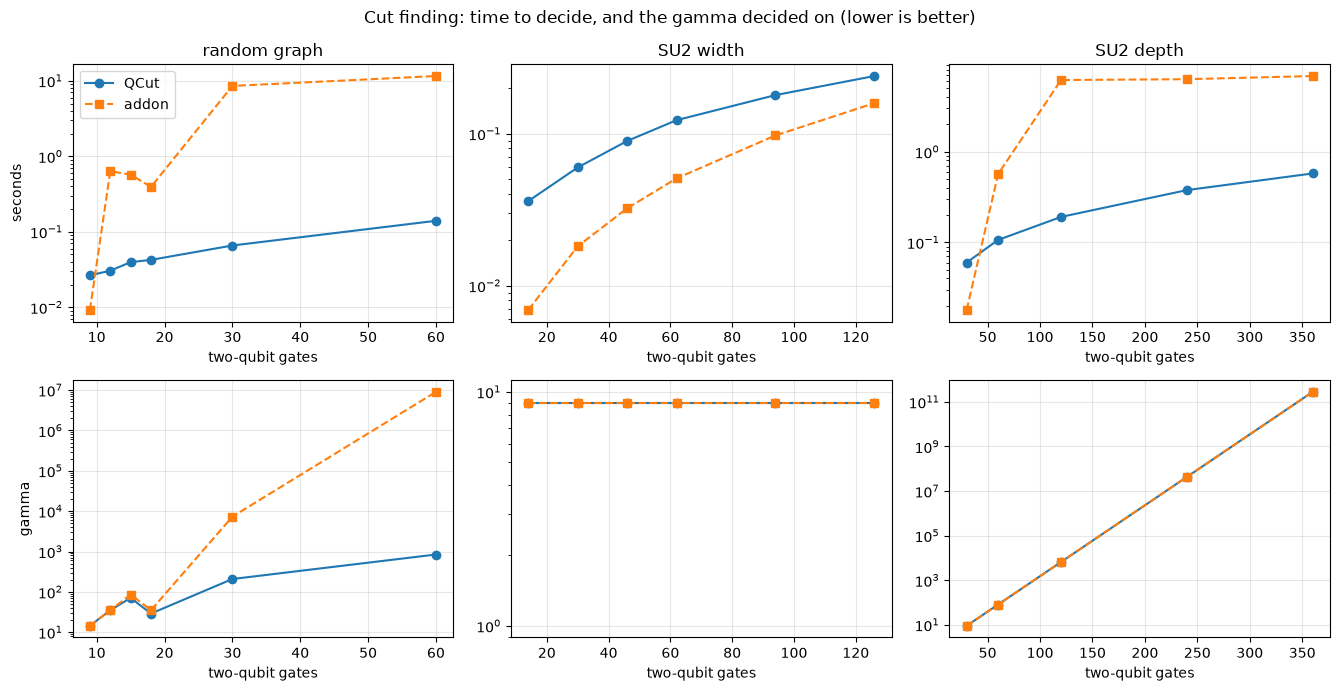

In [12]:
kinds = ["random graph", "SU2 width", "SU2 depth"]
fig, axes = plt.subplots(2, len(kinds), figsize=(4.5 * len(kinds), 7))

for column, kind in enumerate(kinds):
    block = finder[finder.kind == kind]
    for row, metric in enumerate(("seconds", "gamma")):
        ax = axes[row, column]
        for library, marker in (("QCut", "o-"), ("addon", "s--")):
            part = block[block.library == library].sort_values("gates_2q")
            ax.plot(part["gates_2q"], part[metric], marker, label=library)
        ax.set_yscale("log")
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("two-qubit gates")
        if row == 0:
            ax.set_title(kind)
        if column == 0:
            ax.set_ylabel(metric)

axes[0, 0].legend()
fig.suptitle("Cut finding: time to decide, and the gamma decided on (lower is better)")
fig.tight_layout()

## What each library has that the other does not

| | QCut | addon |
| --- | --- | --- |
| Joint cutting of parallel rotation gates | yes | no |
| Wire cuts with classical communication | yes | no |
| Merging consecutive gates on a pair before cutting | yes | no |
| Generic two-qubit gate cut from the gate's own matrix | yes | yes |
| Automatic cut finding | yes | yes |
| Cut finding under a qubit budget | yes | yes |
| Sampling instead of full enumeration | yes | yes |
| Runs on IQM hardware directly | yes | via transpilation |
| Qiskit primitives / Runtime integration | yes | yes |
| Probability reconstruction | yes | no |
| Cut finding with an explicit gamma ceiling | no | yes (`max_gamma`) |